# 函数拟合任务 (NumPy 实现)

## 问题描述
利用 NumPy 搭建一个两层 ReLU 网络来拟合自定义函数。根据通用近似定理，两层 ReLU 网络可以模拟任何连续函数。

## 1. 函数定义与数据采集
我们定义目标函数为：$y = sin(x) + 0.5x$
我们在 $[-π, π]$ 范围内采样生成训练集和测试集。

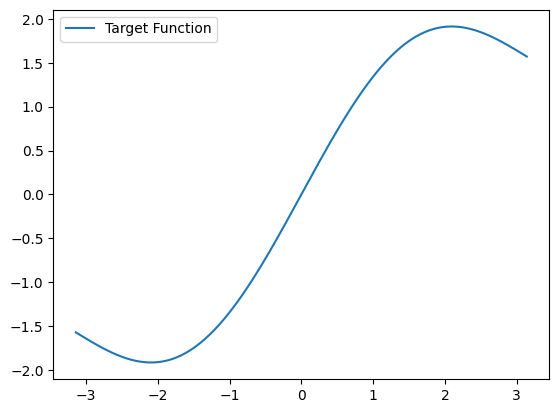

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 定义目标函数
def target_function(x):
    return np.sin(x) + 0.5 * x

# 生成数据
np.random.seed(42)
x_train = np.linspace(-np.pi, np.pi, 1000).reshape(-1, 1)
y_train = target_function(x_train)

x_test = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1)
y_test = target_function(x_test)

plt.plot(x_train, y_train, label='Target Function')
plt.legend()
plt.show()

## 2. 模型描述
网络结构：
- 输入层：1个神经元
- 隐藏层：64个神经元，激活函数为 ReLU
- 输出层：1个神经元
- 损失函数：均方误差 (MSE)

In [2]:
class SimpleNet:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        # 权重初始化 (He initialization 思想)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = lr

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def forward(self, x):
        self.x = x
        self.z1 = np.dot(x, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2

    def backward(self, y_pred, y_true):
        # 计算梯度 (MSE 导数)
        m = y_true.shape[0]
        dz2 = (y_pred - y_true) / m
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = np.dot(self.x.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # 更新参数
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

model = SimpleNet(1, 64, 1, lr=0.01)
epochs = 20000

for epoch in range(epochs):
    y_pred = model.forward(x_train)
    loss = np.mean((y_pred - y_train) ** 2)
    model.backward(y_pred, y_train)
    
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.6f}')

Epoch 0, Loss: 1.631667
Epoch 500, Loss: 0.118752
Epoch 1000, Loss: 0.084012
Epoch 1500, Loss: 0.066882
Epoch 2000, Loss: 0.057207
Epoch 2500, Loss: 0.050201
Epoch 3000, Loss: 0.044104
Epoch 3500, Loss: 0.038441
Epoch 4000, Loss: 0.033240
Epoch 4500, Loss: 0.028674
Epoch 5000, Loss: 0.024769
Epoch 5500, Loss: 0.021412
Epoch 6000, Loss: 0.018492
Epoch 6500, Loss: 0.015938
Epoch 7000, Loss: 0.013704
Epoch 7500, Loss: 0.011767
Epoch 8000, Loss: 0.010099
Epoch 8500, Loss: 0.008677
Epoch 9000, Loss: 0.007473
Epoch 9500, Loss: 0.006461
Epoch 10000, Loss: 0.005613
Epoch 10500, Loss: 0.004904
Epoch 11000, Loss: 0.004311
Epoch 11500, Loss: 0.003815
Epoch 12000, Loss: 0.003399
Epoch 12500, Loss: 0.003048
Epoch 13000, Loss: 0.002749
Epoch 13500, Loss: 0.002493
Epoch 14000, Loss: 0.002271
Epoch 14500, Loss: 0.002076
Epoch 15000, Loss: 0.001902
Epoch 15500, Loss: 0.001745
Epoch 16000, Loss: 0.001604
Epoch 16500, Loss: 0.001476
Epoch 17000, Loss: 0.001361
Epoch 17500, Loss: 0.001258
Epoch 18000, Los

## 3. 拟合效果可视化
在测试集上验证拟合性能。

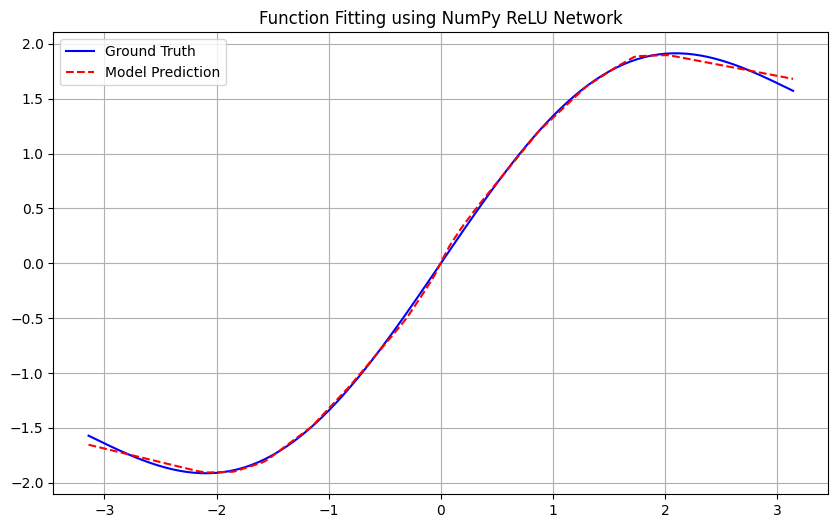

Final Test MSE Loss: 0.000909


In [3]:
y_test_pred = model.forward(x_test)

plt.figure(figsize=(10, 6))
plt.plot(x_test, y_test, 'b-', label='Ground Truth')
plt.plot(x_test, y_test_pred, 'r--', label='Model Prediction')
plt.title('Function Fitting using NumPy ReLU Network')
plt.legend()
plt.grid(True)
plt.show()

final_loss = np.mean((y_test_pred - y_test) ** 2)
print(f'Final Test MSE Loss: {final_loss:.6f}')